# Figures for my Quals Paper

In [216]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs

In [217]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

DON'T PUT ANY ANALYSIS IN THIS NOTEBOOK!!!!!!!!!!!!!!!!!!!!!!

I want you to load datasets and make figures only!

## Load Datasets

In [240]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')

In [429]:
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_cip_masking.nc')
#ds_pbar_grid_grad_bin = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_grad_bin.nc', engine='h5netcdf')

In [430]:
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [431]:
ds_pbar_grid

<xarray.Dataset>
Dimensions:          (PRESSURE_mean: 1001, LON: 120, LAT: 60, LON_left: 120,
                      LAT_left: 60)
Coordinates:
  * PRESSURE_mean    (PRESSURE_mean) int64 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON              (LON) float64 -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT              (LAT) float64 -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * LON_left         (LON_left) float64 -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left         (LAT_left) float64 -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/57)
    CT_sort          (PRESSURE_mean, LON, LAT) float64 ...
    SA_sort          (PRESSURE_mean, LON, LAT) float64 ...
    SPICE_sort       (PRESSURE_mean, LON, LAT) float64 ...
    DENSITY          (PRESSURE_mean, LON, LAT) float64 ...
    CT_sort_m        (PRESSURE_mean, LON, LAT) float64 ...
    SA_sort_m        (PRESSURE_mean, LON, LAT) float64 ...
    ...               ...
    F_SPICE_y        (PRESSURE_mean, LON, LAT) float64 ...
    F_SPICE_xy       (PRESSURE_mean, LON, LAT) float64 ...
    Cp               (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_x         (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_y         (PRESSURE_mean, LON, LAT) float64 ...
    F_heat_xy        (PRESSURE_mean, LON, LAT) float64 ...

In [432]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Introduction

## Methods

### Methods 1

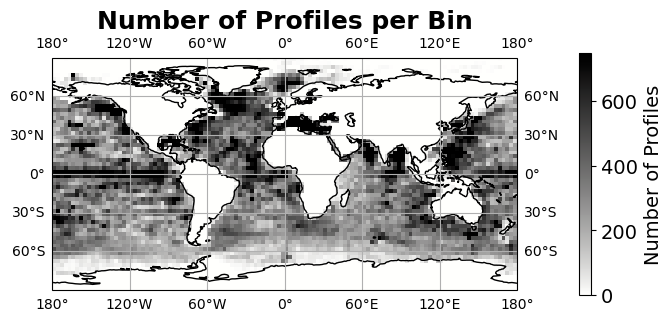

In [472]:
fig = plt.figure(figsize=(8, 3.5))
ax2 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
lon_edges = np.arange(-180, 181, 3)
lat_edges = np.arange(-90, 91, 3)
heatmap, _, _ = np.histogram2d(ds_pbar.LAT.values, ds_pbar.LON.values, bins=[lat_edges, lon_edges])
avg_profiles_3deg = heatmap[heatmap > 0].mean()
std_profiles_3deg = heatmap[heatmap > 0].std()

lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
X, Y = np.meshgrid(lon_centers, lat_centers)

heatmap_plot = ax2.pcolormesh(X, Y, heatmap, cmap=cmo.gray_r, norm=colors.Normalize(vmin=0, vmax=750), transform=ccrs.PlateCarree())
cbar = plt.colorbar(heatmap_plot, ax=ax2, orientation='vertical', pad=0.1, shrink=0.9)
cbar.set_label('Number of Profiles')
ax2.coastlines()
ax2.gridlines(draw_labels=True)
ax2.set_global()
ax2.set_title(f'Number of Profiles per Bin')
fig.savefig("quals_paper/methods/1_profs_map.png", dpi=300, bbox_inches='tight')

### Methods 2

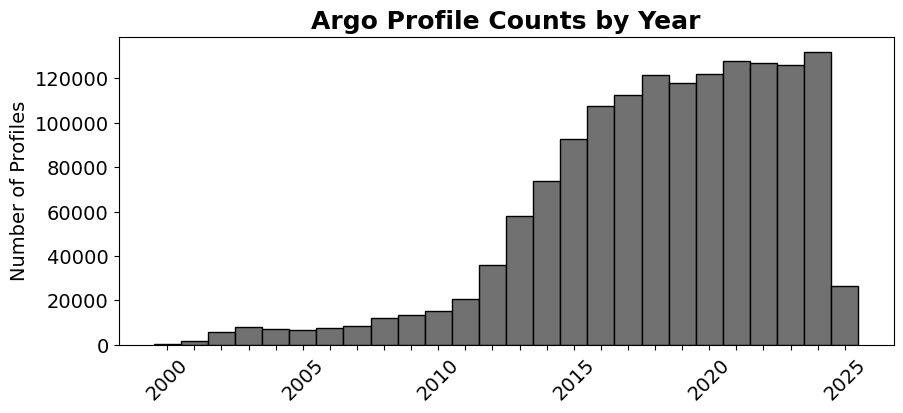

In [473]:
# --- Extract years from profile timestamps ---
years = ds_pbar.TIME.dt.year.values

year_min = years.min()
year_max = years.max()
bins = np.arange(2000, year_max + 2, 1)
counts, edges = np.histogram(years, bins=bins)
centers = edges[:-1] + 0.5

# --- Choose labeling interval: 1, 2, 5, etc. ---
label_every = 5   # <-- change this to 1, 2, 5, 10, etc.

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(centers, counts, width=1, align='center', color=cmo.gray(0.5), edgecolor='k')
ax.set_xticks(centers)
ax.set_xticklabels([str(int(c)) if (i % label_every == 0) else "" for i, c in enumerate(centers)], rotation=45)
ax.set_ylabel("Number of Profiles")
ax.set_title("Argo Profile Counts by Year")

plt.savefig("quals_paper/methods/2_profs_hist.png", dpi=300, bbox_inches='tight')

### Methods 3

LON: -54.81896666666667 LAT: 125.11388166666667


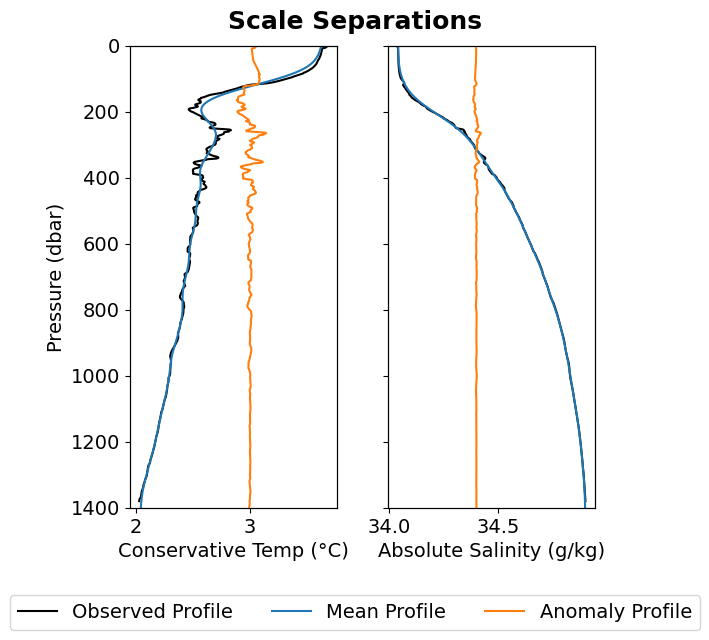

In [474]:
prof = ds_pbar.isel(PROFILE=100000)
fig, axes = plt.subplots(ncols=2, figsize=(6,6), sharey=True)
# LEFT PANEL — CT
ax1 = axes[0]

# Labeled lines (used for legend)
h1 = ax1.plot(prof.CT_sort, prof.PRESSURE_mean, color='k', label='Observed Profile')
h2 = ax1.plot(prof.CT_sort_m, prof.PRESSURE_mean, color='tab:blue', label='Mean Profile')
ax1.set_ylim(1400, 0)
ax1.set_xlabel('Conservative Temp (°C)')
ax1.set_ylabel('Pressure (dbar)')
ax1.set_title('')

# Secondary axis for CT anomaly
ax1b = ax1.twinx()
h3 = ax1b.plot(prof.CT_sort_e + 3, prof.PRESSURE_mean, color='tab:orange', label='Anomaly Profile')
ax1b.set_ylim(1350, 0)
ax1b.set_yticks([])
ax1b.set_ylabel('')
ax1b.tick_params(axis='y', which='both', length=0)


# RIGHT PANEL — SA
ax2 = axes[1]

# SAME colors, but NO labels
ax2.plot(prof.SA_sort, prof.PRESSURE_mean, color='k')
ax2.plot(prof.SA_sort_m, prof.PRESSURE_mean, color='tab:blue')
ax2.set_ylim(1400, 0)
ax2.set_xlabel('Absolute Salinity (g/kg)')
ax2.set_title('')

# Secondary axis for SA anomaly
ax2b = ax2.twinx()
ax2b.plot(prof.SA_sort_e + 34.4, prof.PRESSURE_mean,color='tab:orange')
ax2b.set_ylim(1350, 0)
ax2b.set_yticks([])
ax2b.set_ylabel('')
ax2b.tick_params(axis='y', which='both', length=0)

# COMBINED LEGEND (below figure)
handles = h1 + h2 + h3
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3)
fig.suptitle("Scale Separations", y=0.94, weight='bold', size=18)

plt.subplots_adjust(wspace=0.25)
print(f'LON: {prof.LAT.data} LAT: {prof.LON.data}')
plt.savefig('quals_paper/methods/3_-55_125', dpi=300, bbox_inches='tight')

depth: 1000 m


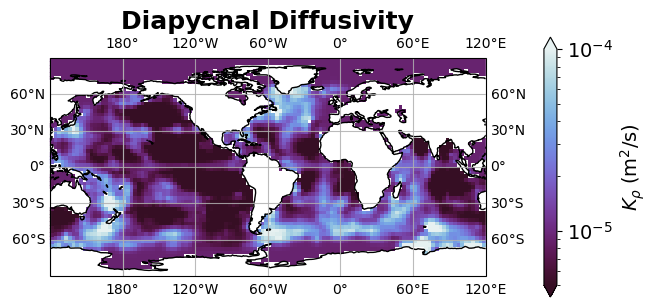

In [475]:
fig = plt.figure(figsize=(7.5, 3.75))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-60))

depth = 1000
shrink, pad = 0.9, 0.1

K_rho_p.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.dense_r, norm=colors.LogNorm(5e-6, 1e-4), transform=ccrs.PlateCarree(), 
                                                        cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': r'$K_\rho \; (\mathrm{m}^2/\mathrm{s})$'}, ax=ax)
ax.coastlines()
ax.gridlines(draw_labels=True, alpha=0.85)
ax.set_title('Diapycnal Diffusivity')

print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
plt.savefig(f"quals_paper/methods/4_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png",dpi=300, bbox_inches='tight')

## Results

### Results 1

depth: 1000 m


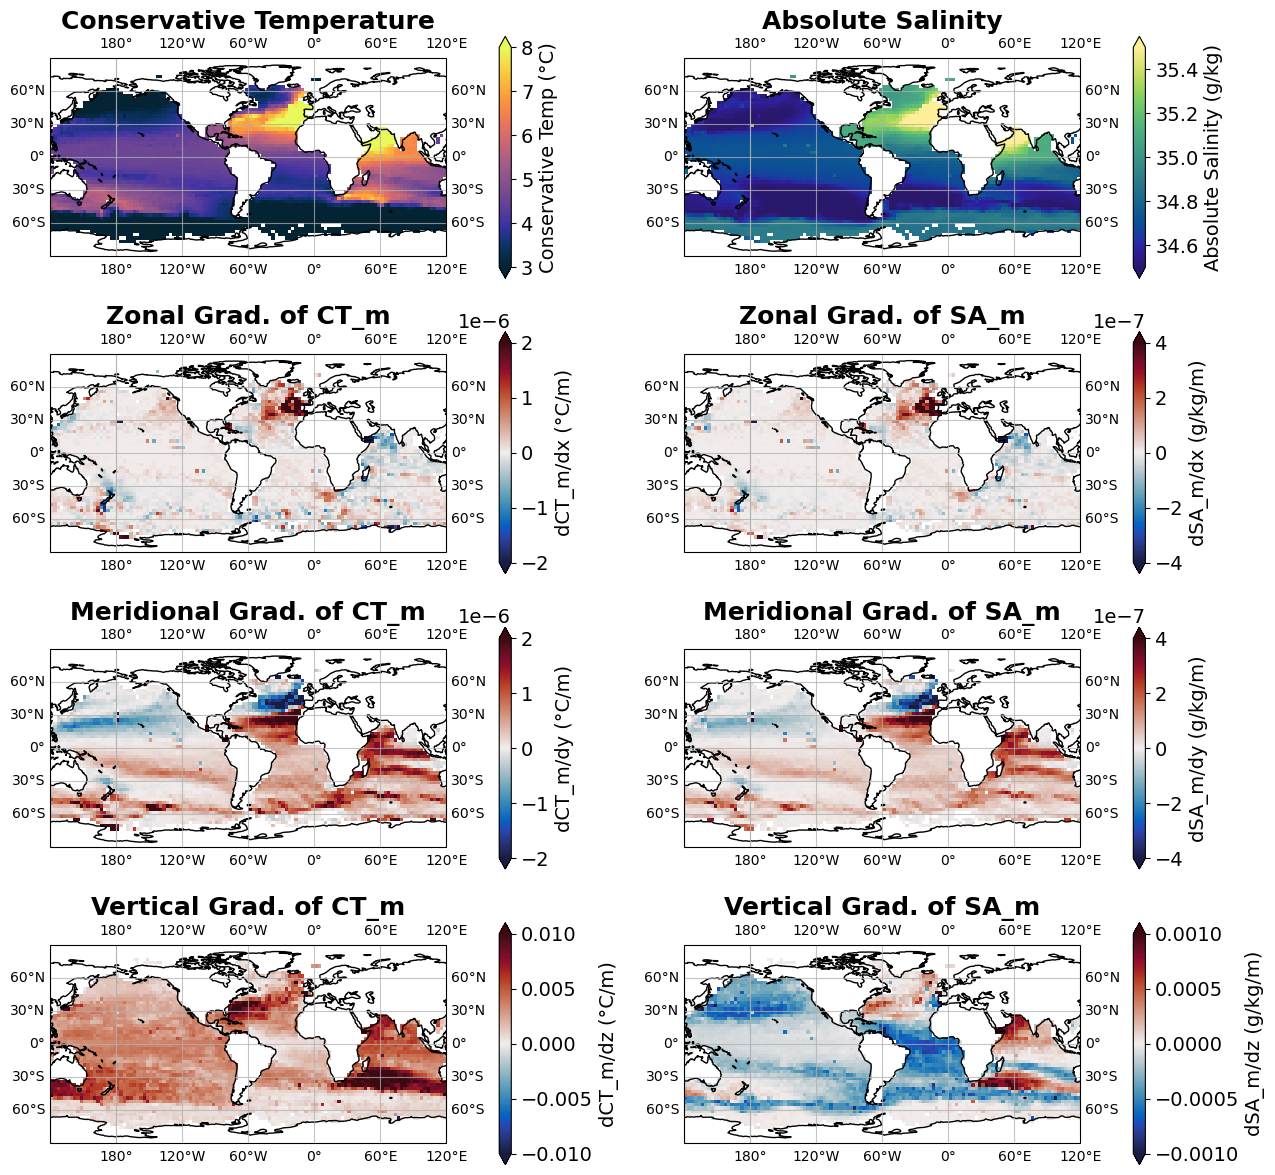

In [483]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("CT_sort", 1, cmo.thermal, (3,8), "Conservative Temp (°C)", "Conservative Temperature"),
    ("SA_sort", 1, cmo.haline, (34.5, 35.5), "Absolute Salinity (g/kg)", "Absolute Salinity"),
    ("dCT_m_dx", 1, cmo.balance, (-2e-6, 2e-6), "dCT_m/dx (°C/m)", "Zonal Grad. of CT_m"),
    ("dSA_m_dx", 1, cmo.balance, (-4e-7, 4e-7), "dSA_m/dx (g/kg/m)", "Zonal Grad. of SA_m"),
    ("dCT_m_dy", 1, cmo.balance, (-2e-6, 2e-6), "dCT_m/dy (°C/m)", "Meridional Grad. of CT_m"),
    ("dSA_m_dy", 1, cmo.balance, (-4e-7, 4e-7), "dSA_m/dy (g/kg/m)", "Meridional Grad. of SA_m"),
    ("dCT_m_dp", 1, cmo.balance, (-1e-2, 1e-2), "dCT_m/dz (°C/m)", "Vertical Grad. of CT_m"),
    ("dSA_m_dp", 1, cmo.balance, (-1e-3, 1e-3), "dSA_m/dz (g/kg/m)", "Vertical Grad. of SA_m"),]

# --- Helper function to plot each panel ---
def plot_panel(ax, varname, scale, cmap, vlims, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')*scale

    da.plot(x='LON', y='LAT', cmap=cmap, transform=ccrs.PlateCarree(), vmin=vlims[0] if isinstance(vlims, tuple) else None, vmax=vlims[1] if isinstance(vlims, tuple) else None,
        robust=True if vlims == "robust" else False, ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)
    
    # Title inside the panel, in gray
    ax.set_title(title)

# --- Create figure and loop ---
fig, axes = plt.subplots(4, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, scale, cmap, vlims, cbar_label, title = fields[i]
    plot_panel(ax, var, scale, cmap, vlims, cbar_label, title)

plt.subplots_adjust(wspace=0.2, hspace=0.1)
plt.savefig(f"quals_paper/results/1_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")

### Results 2

/tmp/ipykernel_3766259/826824908.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_3766259/826824908.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())


lon: -28.5 m


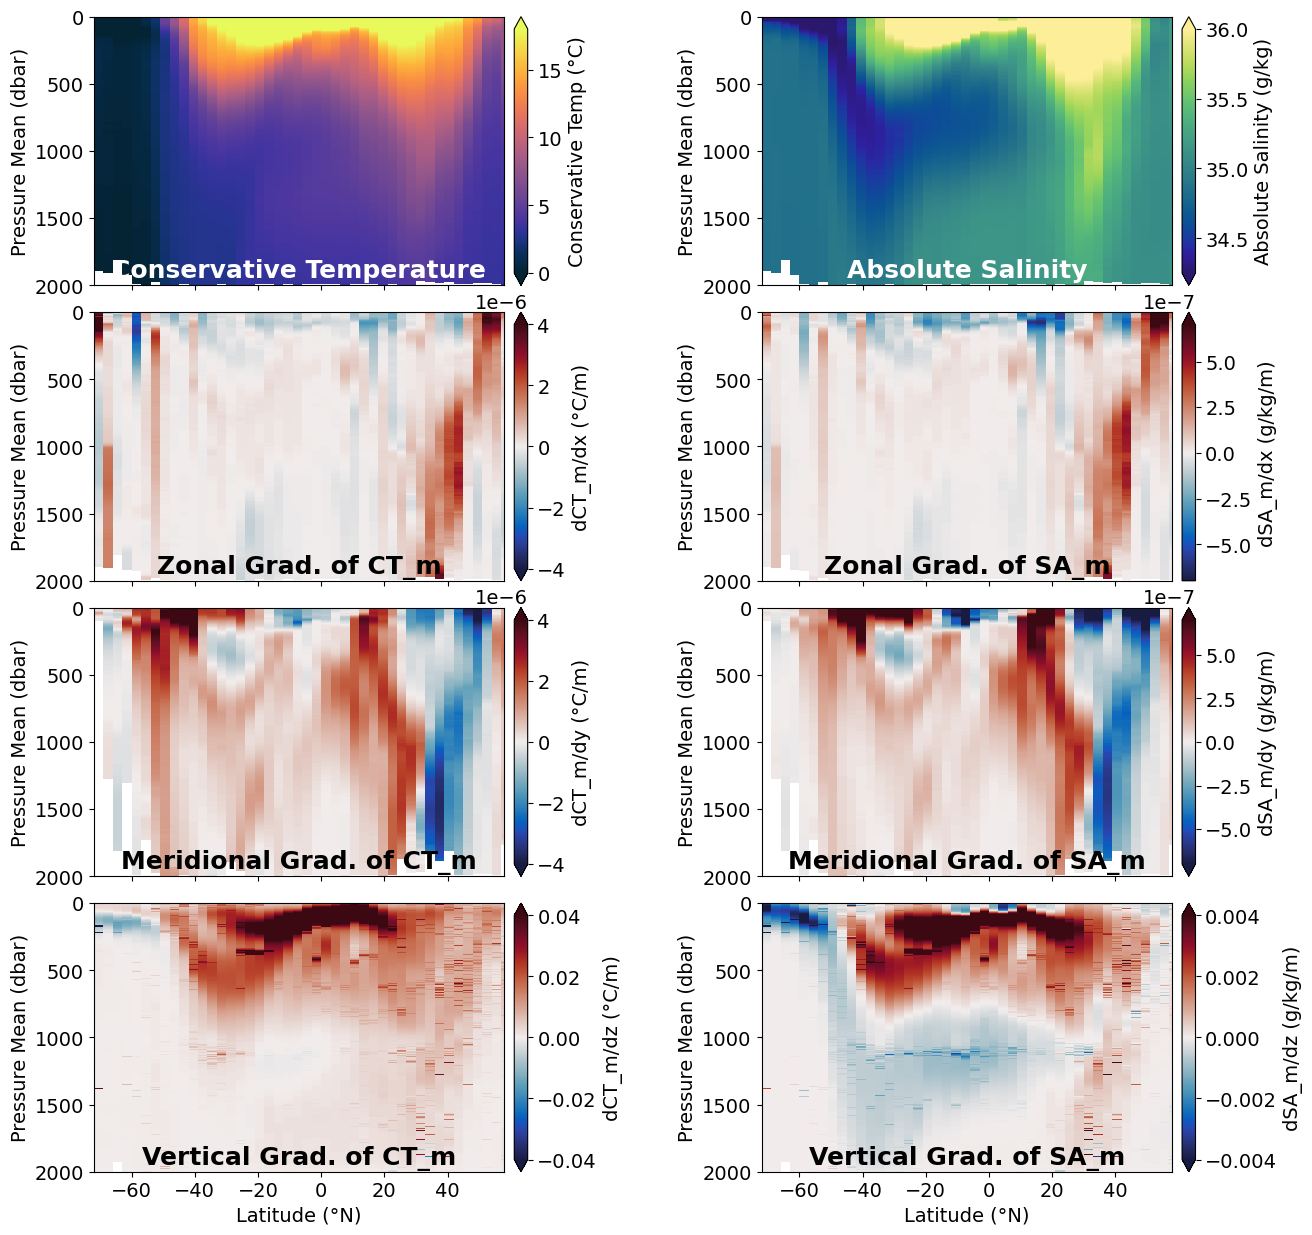

In [489]:
lon = -28
shrink, pad = 1, 0.02

# --- Configuration for each subplot ---
# --- Configuration for each subplot ---
fields = [
    ("CT_sort", 1, cmo.thermal, (0,18), "Conservative Temp (°C)", "Conservative Temperature", "white"),
    ("SA_sort", 1, cmo.haline, (34.25, 36), "Absolute Salinity (g/kg)", "Absolute Salinity", "white"),
    ("dCT_m_dx", 1, cmo.balance, (-4e-6, 4e-6), "dCT_m/dx (°C/m)", "Zonal Grad. of CT_m", "k"),
    ("dSA_m_dx", 1, cmo.balance, (-7e-7, 7e-7), "dSA_m/dx (g/kg/m)", "Zonal Grad. of SA_m", "k"),
    ("dCT_m_dy", 1, cmo.balance, (-4e-6, 4e-6), "dCT_m/dy (°C/m)", "Meridional Grad. of CT_m", "k"),
    ("dSA_m_dy", 1, cmo.balance, (-7e-7, 7e-7), "dSA_m/dy (g/kg/m)", "Meridional Grad. of SA_m", "k"),
    ("dCT_m_dp", 1, cmo.balance, (-4e-2, 4e-2), "dCT_m/dz (°C/m)", "Vertical Grad. of CT_m", "k"),
    ("dSA_m_dp", 1, cmo.balance, (-4e-3, 4e-3), "dSA_m/dz (g/kg/m)", "Vertical Grad. of SA_m", "k"),]

# --- Helper function to plot each panel ---
def plot_panel(ax, varname, scale, cmap, vlims, cbar_label, title, color, is_bottom_row):
    da = ds_pbar_grid[varname].sel(LON=lon, method='nearest')*scale

    da.plot(x='LAT', y='PRESSURE_mean', cmap=cmap, vmin=vlims[0] if isinstance(vlims, tuple) else None, vmax=vlims[1] if isinstance(vlims, tuple) else None,
        robust=True if vlims == "robust" else False, ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.set_xlim(-72, 58)
    ax.set_ylim(2000, 0)
    ax.set_ylabel("Pressure Mean (dbar)")

    # Handle x‑labels and tick labels
    if is_bottom_row:
        ax.set_xlabel("Latitude (°N)")
        ax.set_xticklabels(ax.get_xticklabels())
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # Title inside the panel, in gray
    ax.text(0.5, 0.1, title, transform=ax.transAxes, ha='center', va='top', fontweight='bold', color=color, fontsize=plt.rcParams['axes.titlesize'])
    ax.set_title('')

# --- Create figure and loop ---
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, scale, cmap, vlims, cbar_label, title, color = fields[i]
    is_bottom_row = i >= 6   # panels 6 and 7 (0‑indexed) are bottom row
    plot_panel(ax, var, scale, cmap, vlims, cbar_label, title, color, is_bottom_row)

plt.subplots_adjust(wspace=0.35, hspace=0.1)
plt.savefig(f"quals_paper/results/2_{ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}.png", dpi=300, bbox_inches='tight')
print(f"lon: {ds_pbar_grid.sel(LON=lon, method='nearest').LON.data} m")

### Results 3

depth: 1000 m


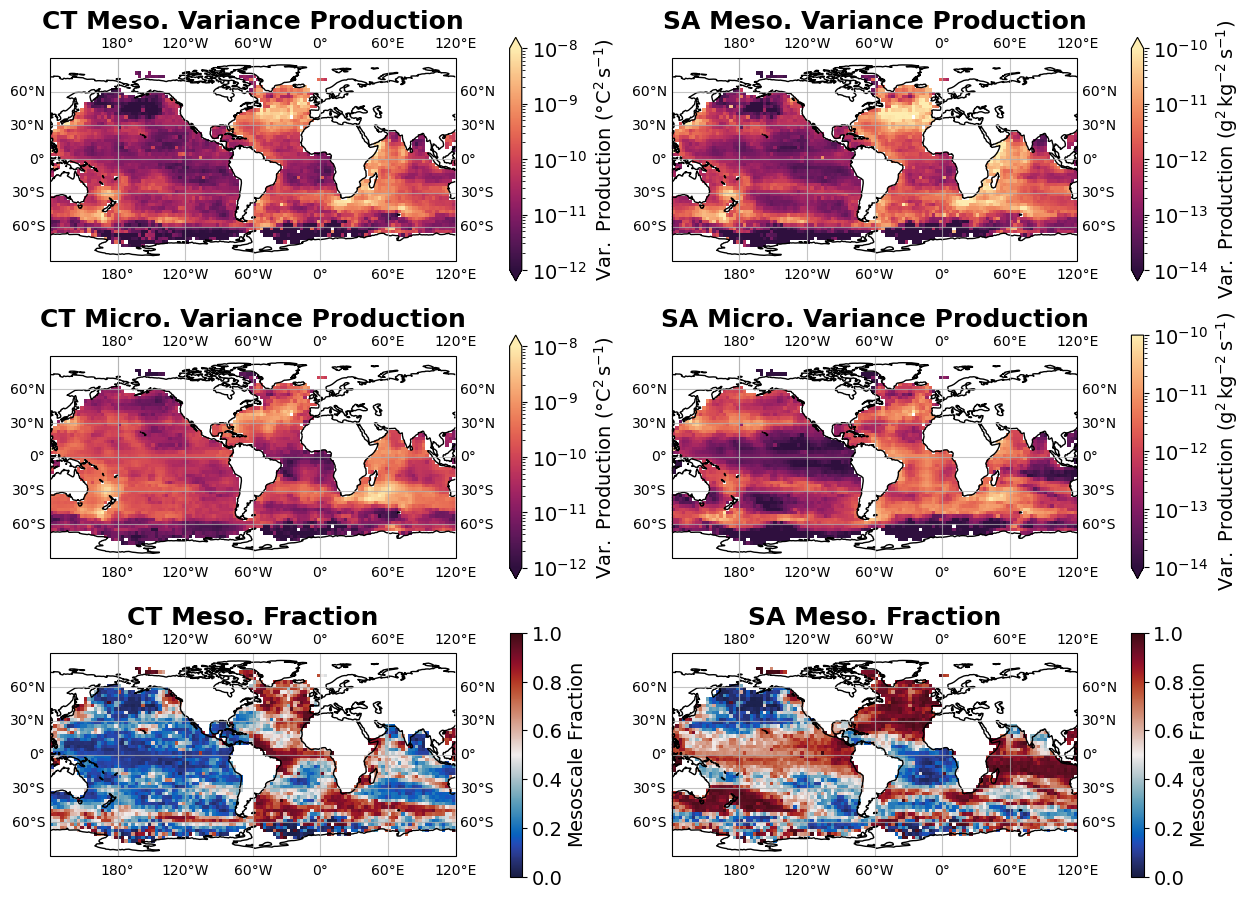

In [465]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("CT_e_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", r"$\mathrm{Var.\ Production\ (°C^2\,s^{-1})}$", "CT Meso. Variance Production"),

    ("SA_e_VPR", cmo.matter_r, (1e-14, 1e-10), "log", r"$\mathrm{Var.\ Production\ (g^2\,kg^{-2}\,s^{-1})}$", "SA Meso. Variance Production"),

    ("CT_m_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", r"$\mathrm{Var.\ Production\ (°C^2\,s^{-1})}$", "CT Micro. Variance Production"),

    ("SA_m_VPR", cmo.matter_r, (1e-14, 1e-10), "log", r"$\mathrm{Var.\ Production\ (g^2\,kg^{-2}\,s^{-1})}$", "SA Micro. Variance Production"),

    ("CT_meso_frac", cmo.balance, (0, 1), "linear", r"$\mathrm{Mesoscale\ Fraction}$", "CT Meso. Fraction"),

    ("SA_meso_frac", cmo.balance, (0, 1), "linear", r"$\mathrm{Mesoscale\ Fraction}$", "SA Meso. Fraction"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)

    # Title inside panel
    ax.set_title(title)

# --- Create figure and loop ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11.25), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
plt.savefig(f"quals_paper/results/3_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")

### Results 4

/tmp/ipykernel_3766259/3205966957.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_3766259/3205966957.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())


lon: -28.5


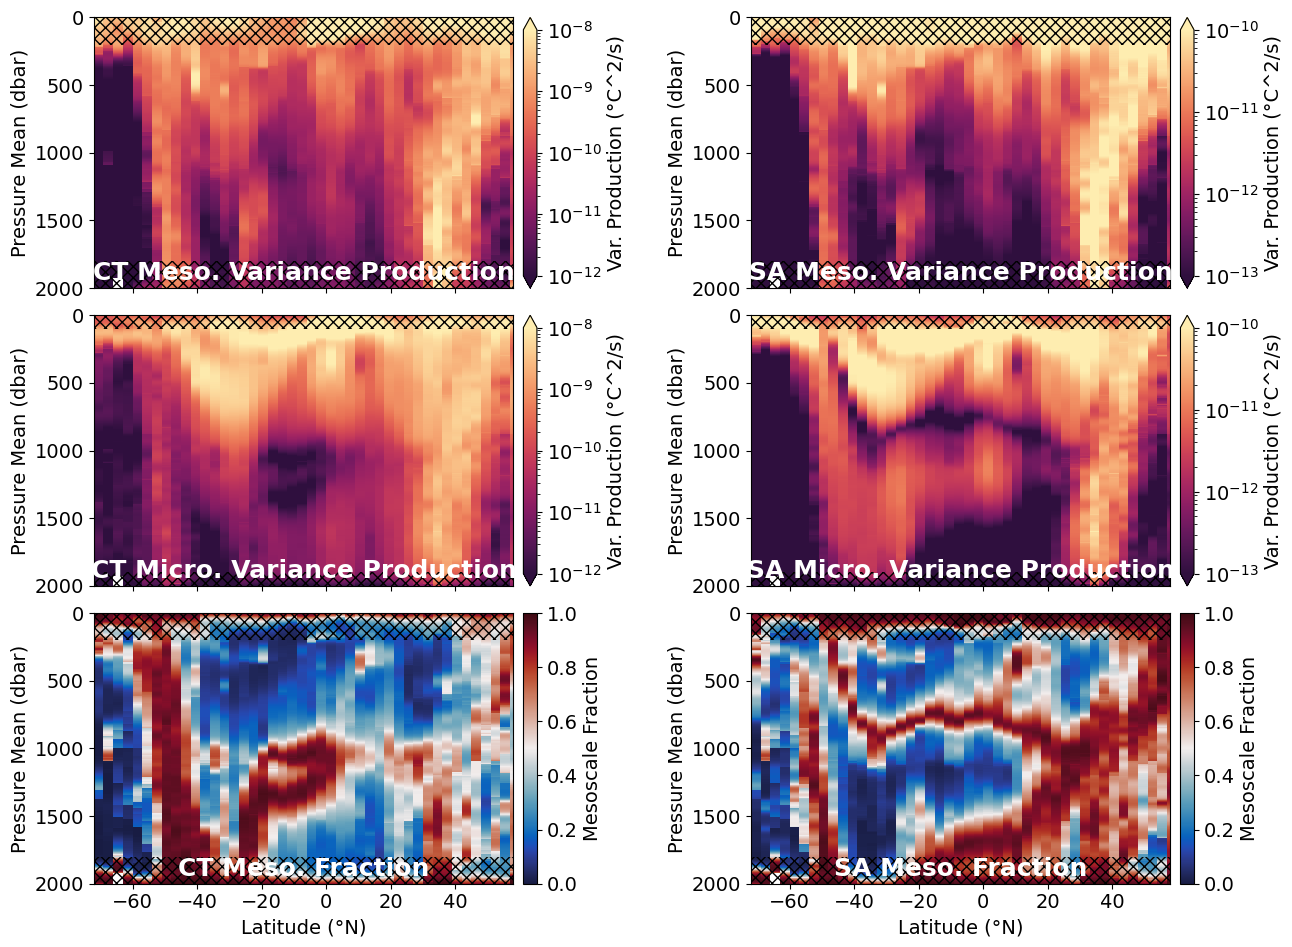

In [490]:
lon = -28
shrink, pad = 1, 0.02

# --- Configuration for each subplot ---
fields = [
    ("CT_e_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", "Var. Production (°C^2/s)", "CT Meso. Variance Production", 200),
    ("SA_e_VPR", cmo.matter_r, (1e-13, 1e-10),  "log", "Var. Production (°C^2/s)", "SA Meso. Variance Production", 200),
    ("CT_m_VPR", cmo.matter_r, (1e-12, 1e-8),  "log", "Var. Production (°C^2/s)", "CT Micro. Variance Production", 100),
    ("SA_m_VPR", cmo.matter_r, (1e-13, 1e-10),  "log", "Var. Production (°C^2/s)", "SA Micro. Variance Production", 100),
    ("CT_meso_frac", cmo.balance, (0, 1),      "linear", "Mesoscale Fraction", "CT Meso. Fraction", 200),
    ("SA_meso_frac", cmo.balance, (0, 1),      "linear", "Mesoscale Fraction", "SA Meso. Fraction", 200),]

# --- Helper function to plot each panel ---
def add_hatching(ax, thickness):
    # Top region (0–thickness)
    ax.axhspan(0, thickness, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)

    # Bottom region (2000–2000-thickness)
    ax.axhspan(2000 - thickness, 2000, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)
    
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title, is_bottom_row, thickness):
    da = ds_pbar_grid[varname].sel(LON=lon, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LAT', y='PRESSURE_mean', cmap=cmap, norm=norm, ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.set_xlim(-72, 58)
    ax.set_ylim(2000, 0)
    ax.set_ylabel("Pressure Mean (dbar)")

    # Handle x‑labels and tick labels
    if is_bottom_row:
        ax.set_xlabel("Latitude (°N)")
        ax.set_xticklabels(ax.get_xticklabels())
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # Title inside the panel, in gray
    ax.text(0.5, 0.1, title, transform=ax.transAxes, ha='center', va='top', fontweight='bold', color='white', fontsize=plt.rcParams['axes.titlesize'])
    ax.set_title('')

    # Add hashed regions
    add_hatching(ax, thickness)

# --- Create figure and loop ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11.25))
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title, thickness = fields[i]
    is_bottom_row = i >=4
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title, is_bottom_row, thickness)

plt.subplots_adjust(wspace=0.3, hspace=0.1)
plt.savefig(f"quals_paper/results/4_{ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}.png", dpi=300, bbox_inches='tight')
print(f"lon: {ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}")

### Results 5

depth: 1000 m


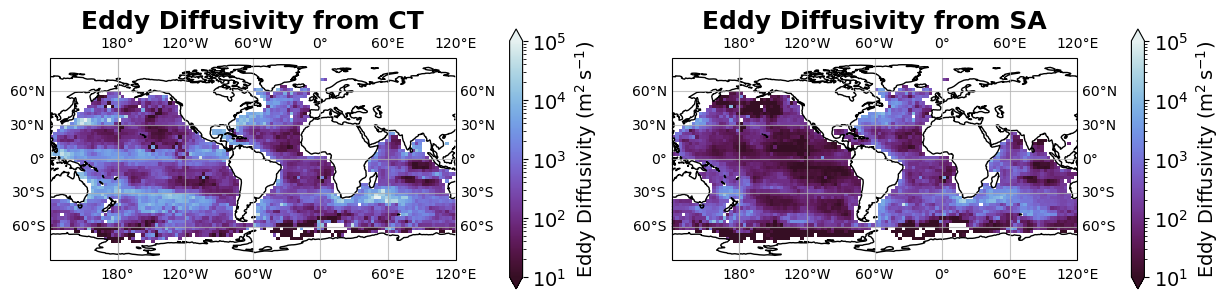

In [470]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from CT"),
    ("K_e_SA", cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from SA"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)

    # Title inside panel
    ax.set_title(title)

# --- Create figure and loop ---
fig, axes = plt.subplots(1, 2, figsize=(15, 3.75), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
plt.savefig(f"quals_paper/results/5_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")

depth: 1000 m
Comparison to Sevellec (2025)


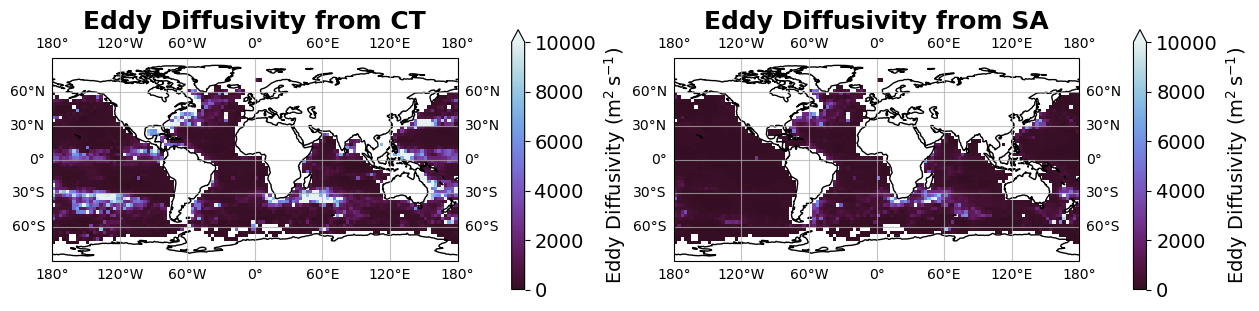

In [462]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", cmo.dense_r, (0, 10*1e3), "lin", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from CT"),
    ("K_e_SA", cmo.dense_r, (0, 10*1e3), "lin", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", "Eddy Diffusivity from SA"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)

    # Title inside panel
    ax.set_title(title)

# --- Create figure and loop ---
fig, axes = plt.subplots(1, 2, figsize=(15, 3.75), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
plt.savefig(f"quals_paper/results/5_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
print("Comparison to Sevellec (2025)")

### Results 6

lon: -28.5


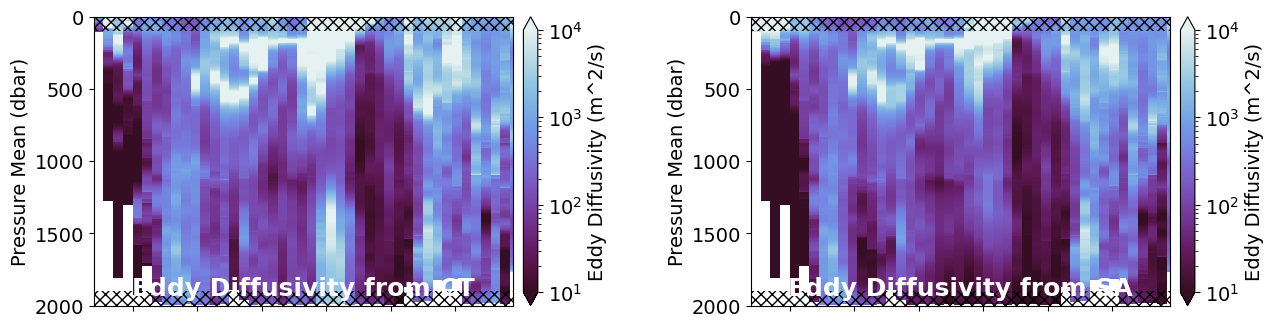

In [491]:
lon = -28
shrink, pad = 1, 0.02

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", cmo.dense_r, (1e1, 1e4), "log", "Eddy Diffusivity (m^2/s)", "Eddy Diffusivity from CT", 100),
    ("K_e_SA", cmo.dense_r, (1e1, 1e4), "log", "Eddy Diffusivity (m^2/s)", "Eddy Diffusivity from SA", 100),]

# --- Helper function to plot each panel ---
def add_hatching(ax, thickness):
    # Top region (0–thickness)
    ax.axhspan(0, thickness, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)

    # Bottom region (2000–2000-thickness)
    ax.axhspan(2000 - thickness, 2000, facecolor='none', edgecolor='k', hatch='xxx', linewidth=0)
    
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title, is_bottom_row, thickness):
    da = ds_pbar_grid[varname].sel(LON=lon, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LAT', y='PRESSURE_mean', cmap=cmap, norm=norm, ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.set_xlim(-72, 58)
    ax.set_ylim(2000, 0)
    ax.set_ylabel("Pressure Mean (dbar)")

    # Handle x‑labels and tick labels
    if is_bottom_row:
        ax.set_xlabel("Latitude (°N)")
        ax.set_xticklabels(ax.get_xticklabels())
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # Title inside the panel, in gray
    ax.text(0.5, 0.1, title, transform=ax.transAxes, ha='center', va='top', fontweight='bold', color='white', fontsize=plt.rcParams['axes.titlesize'])
    ax.set_title('')

    # Add hashed regions
    add_hatching(ax, thickness)

# --- Create figure and loop ---
fig, axes = plt.subplots(1, 2, figsize=(15, 3.75))
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, cmap, vlims, norm_type, cbar_label, title, thickness = fields[i]
    is_bottom_row = i >=2
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title, is_bottom_row, thickness)

plt.subplots_adjust(wspace=0.3, hspace=0.1)
plt.savefig(f"quals_paper/results/6_{ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}.png", dpi=300, bbox_inches='tight')
print(f"lon: {ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}")

### Results 7

depth: 1000


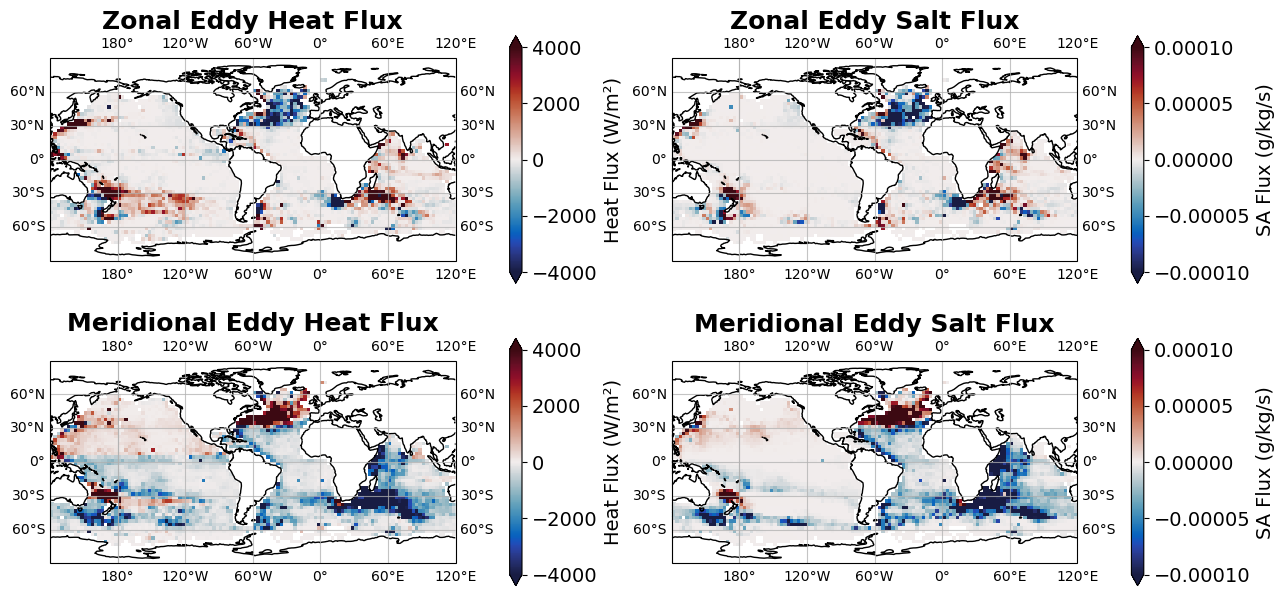

In [494]:
depth = 1000
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("F_heat_x", cmo.balance, (-4e3, 4e3), "lin", "Heat Flux (W/m²)", "Zonal Eddy Heat Flux"),
    ("F_SA_x",   cmo.balance, (-1e-4,1e-4), "lin", "SA Flux (g/kg/s)", "Zonal Eddy Salt Flux"),
    ("F_heat_y", cmo.balance, (-4e3, 4e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux"),
    ("F_SA_y",   cmo.balance, (-1e-4,1e-4), "lin", "SA Flux (g/kg/s)", "Meridional Eddy Salt Flux"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose normalization
    if norm_type == "symlog":
        linthresh = vlims[0]  # linear region around zero
        vmax = vlims[1]
        norm = SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax)
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    # --- Base map ---
    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    # --- Decorations ---
    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)
    ax.set_title(title)


# --- Create figure and loop ---
fig, axes = plt.subplots(
    2, 2, figsize=(15, 7.5),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)}
)
axes = axes.ravel()

for i, ax in enumerate(axes[:len(fields)]):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

# Hide the extra subplot
for ax in axes[len(fields):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
plt.savefig(f"quals_paper/results/7_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}")

depth: 500


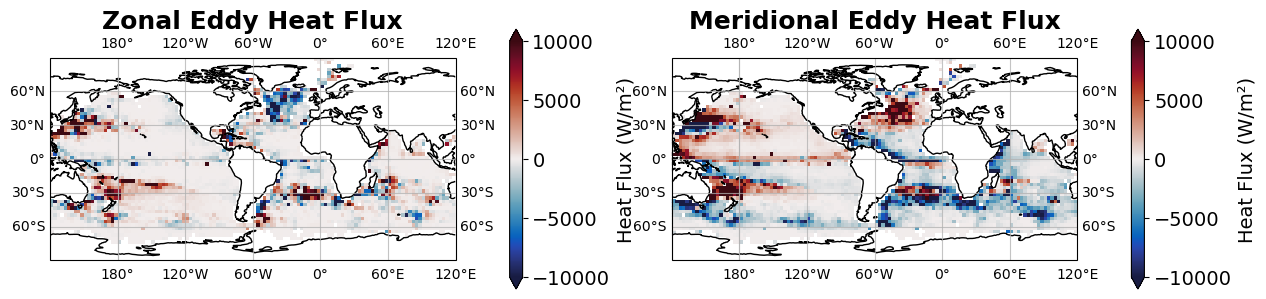

In [444]:
depth = 500
shrink, pad = 0.9, 0.1

# --- Configuration for each subplot ---
fields = [
    ("F_heat_x", cmo.balance, (-1e4, 1e4), "lin", "Heat Flux (W/m²)", "Zonal Eddy Heat Flux"),
    ("F_heat_y", cmo.balance, (-1e4, 1e4), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux"),]


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose normalization
    if norm_type == "symlog":
        linthresh = vlims[0]  # linear region around zero
        vmax = vlims[1]
        norm = SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax)
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    # --- Base map ---
    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    # --- Decorations ---
    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.75)
    ax.set_title(title)


# --- Create figure and loop ---
fig, axes = plt.subplots(
    1, 2, figsize=(15, 3.75),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)}
)
axes = axes.ravel()

for i, ax in enumerate(axes[:len(fields)]):
    var, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title)

# Hide the extra subplot
for ax in axes[len(fields):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.15, hspace=0.1)
#plt.savefig(f"quals_paper/results/7_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300, bbox_inches='tight')
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}")

$$<u_tC_t>_y \approx K_\rho * \frac{(\partial_zC_e)^2}{|\nabla_nC_m|^2} * \partial_xC_m * \rho *c_p$$

### Results 8

lon: -28.5


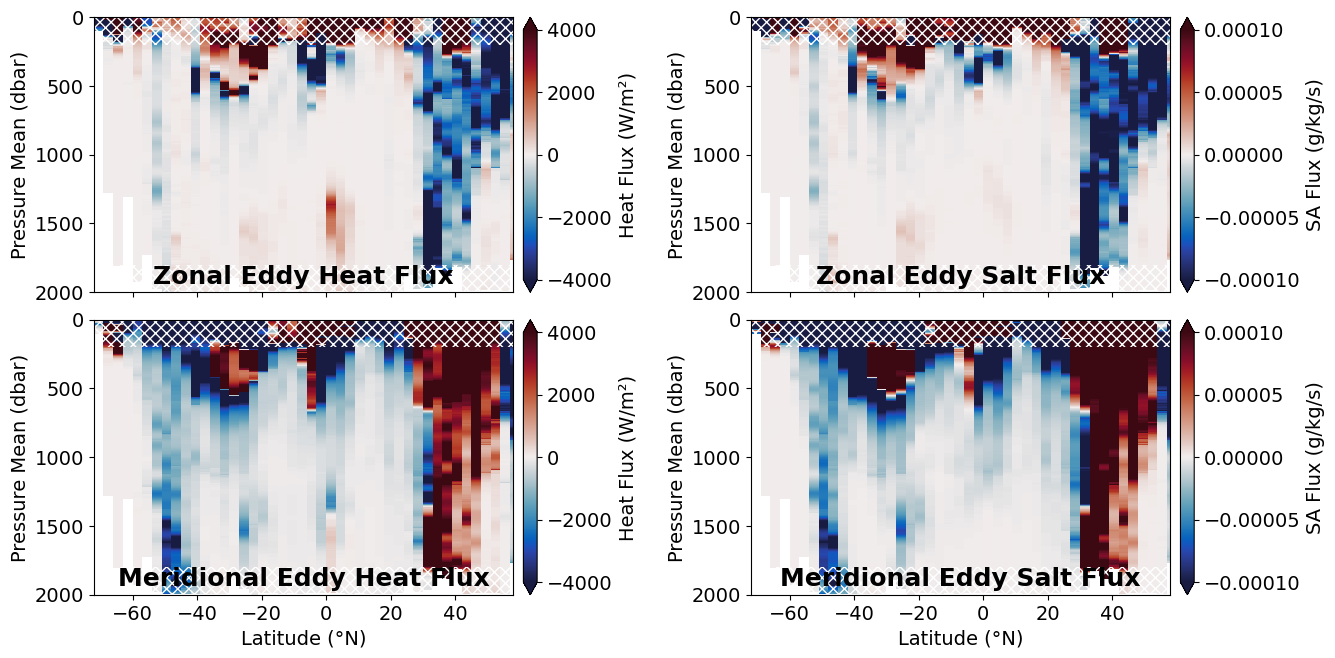

In [496]:
from matplotlib.colors import SymLogNorm

lon = -28
shrink, pad = 1, 0.02

# --- Configuration for each subplot ---
fields = [
    ("F_heat_x", cmo.balance, (-1e4, 1e3), "lin", "Heat Flux (W/m²)", "Zonal Eddy Heat Flux", 200),
    ("F_SA_x",   cmo.balance, (-1e-4,1e-4), "lin", "SA Flux (g/kg/s)", "Zonal Eddy Salt Flux", 200),
    ("F_heat_y", cmo.balance, (-4e3, 4e3), "lin", "Heat Flux (W/m²)", "Meridional Eddy Heat Flux", 200),
    ("F_SA_y",   cmo.balance, (-1e-4,1e-4), "lin", "SA Flux (g/kg/s)", "Meridional Eddy Salt Flux", 200),]


# --- Helper function to add hatching ---
def add_hatching(ax, thickness):
    ax.axhspan(0, thickness, facecolor='none', edgecolor='white', hatch='xxx', linewidth=0)
    ax.axhspan(2000 - thickness, 2000, facecolor='none', edgecolor='white', hatch='xxx', linewidth=0)


# --- Helper function to plot each panel ---
def plot_panel(ax, varname, cmap, vlims, norm_type, cbar_label, title, is_bottom_row, thickness):
    da = ds_pbar_grid[varname].sel(LON=lon, method='nearest')

    # --- Normalization ---
    if norm_type == "symlog":
        vmin, vmax = vlims

        # Widen the linear region so the center isn't too dark
        linthresh = vmin * 50   # adjust factor as needed

        norm = SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax
        )
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    # --- Base plot ---
    da.plot(
        x='LAT', y='PRESSURE_mean',
        cmap=cmap,
        norm=norm,
        ax=ax,
        cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label}
    )

    # --- Axes formatting ---
    ax.set_xlim(-72, 58)
    ax.set_ylim(2000, 0)
    ax.set_ylabel("Pressure Mean (dbar)")

    if is_bottom_row:
        ax.set_xlabel("Latitude (°N)")
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # Title inside panel
    ax.text(
        0.5, 0.1, title,
        transform=ax.transAxes,
        ha='center', va='top',
        fontweight='bold', color='k',
        fontsize=plt.rcParams['axes.titlesize']
    )
    ax.set_title('')

    # --- Add hashed regions ---
    add_hatching(ax, thickness)


# --- Create figure and loop ---
fig, axes = plt.subplots(2, 2, figsize=(15, 7.5))
axes = axes.ravel()

for i, ax in enumerate(axes[:len(fields)]):
    var, cmap, vlims, norm_type, cbar_label, title, thickness = fields[i]
    is_bottom_row = i >= 2
    plot_panel(ax, var, cmap, vlims, norm_type, cbar_label, title, is_bottom_row, thickness)

# Hide unused subplot
for ax in axes[len(fields):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.3, hspace=0.1)
plt.savefig(f"quals_paper/results/8_{ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}.png", dpi=300, bbox_inches='tight')
print(f"lon: {ds_pbar_grid.sel(LON=lon, method='nearest').LON.data}")

## Discussion

### Discussion 1

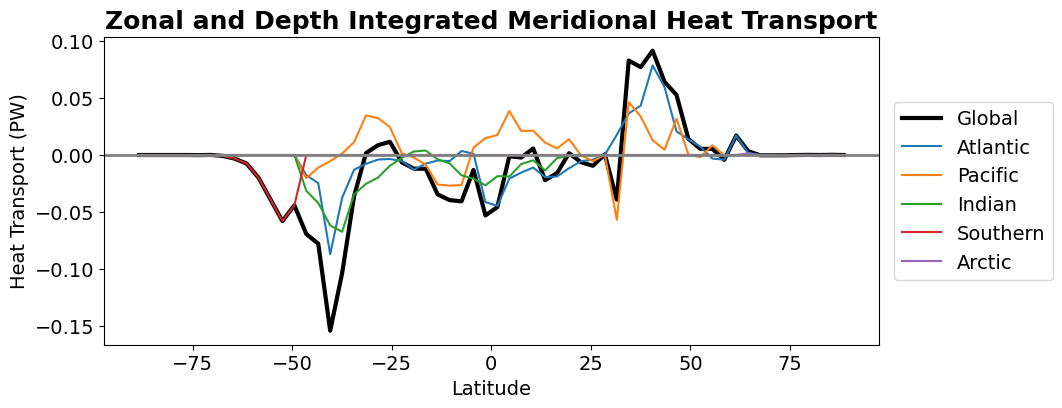

In [471]:
# ---------------------------------------------------------
# Compute zonal metric Δx
# ---------------------------------------------------------
R = 6371e3
dlon = np.deg2rad(float(ds_pbar_grid.LON[1] - ds_pbar_grid.LON[0]))
lat_rad = np.deg2rad(ds_pbar_grid.LAT)

dx = R * np.cos(lat_rad) * dlon
dx_da = xr.DataArray(dx, dims=['LAT'])
dx_3d = dx_da.broadcast_like(ds_pbar_grid.F_heat_y)

# ---------------------------------------------------------
# Add constant Δz (m)
# ---------------------------------------------------------
delta_z = 2.0   # choose your constant vertical thickness (meters)

# ---------------------------------------------------------
# Compute basin-specific meridional heat transport
# ---------------------------------------------------------
Fy_dx_dz = ds_pbar_grad.F_heat_y.sel(PRESSURE_mean=slice(200,2000)) * dx_3d * delta_z

transport_atl    = Fy_dx_dz.where(ds_pbar_grad.basin==1).sum(dim=['PRESSURE_mean', 'LON'])
transport_pac    = Fy_dx_dz.where(ds_pbar_grad.basin==2).sum(dim=['PRESSURE_mean', 'LON'])
transport_ind    = Fy_dx_dz.where(ds_pbar_grad.basin==3).sum(dim=['PRESSURE_mean', 'LON'])
transport_sou    = Fy_dx_dz.where(ds_pbar_grad.basin==10).sum(dim=['PRESSURE_mean', 'LON'])
transport_art    = Fy_dx_dz.where(ds_pbar_grad.basin==11).sum(dim=['PRESSURE_mean', 'LON'])
transport_global = Fy_dx_dz.where(ds_pbar_grad.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])

# ---------------------------------------------------------
# Plot all curves
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(ds_pbar_grid.LAT, transport_global / 1e15, label='Global',   color='k',linewidth=3)
ax.plot(ds_pbar_grid.LAT, transport_atl    / 1e15, label='Atlantic', color='tab:blue')
ax.plot(ds_pbar_grid.LAT, transport_pac    / 1e15, label='Pacific',  color='tab:orange')
ax.plot(ds_pbar_grid.LAT, transport_ind    / 1e15, label='Indian',   color='tab:green')
ax.plot(ds_pbar_grid.LAT, transport_sou    / 1e15, label='Southern', color='tab:red')
ax.plot(ds_pbar_grid.LAT, transport_art    / 1e15, label='Arctic',   color='tab:purple')
ax.axhline(0, color='gray', linewidth=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Heat Transport (PW)')
ax.set_title('Zonal and Depth Integrated Meridional Heat Transport')

# Legend to the right, vertically centered
ax.legend(loc='center left',bbox_to_anchor=(1.02, 0.5),borderaxespad=0)
plt.savefig('quals_paper/discussion/1_heat_transport.png', dpi=300, bbox_inches='tight')

## Interp Methods Plot

In [447]:
ds_p_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_p_grid_copilot.nc')
ds_r_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_r_grid_copilot.nc')

Text(0.5, 1.0, 'CT on Av. Isopycnal Depth')

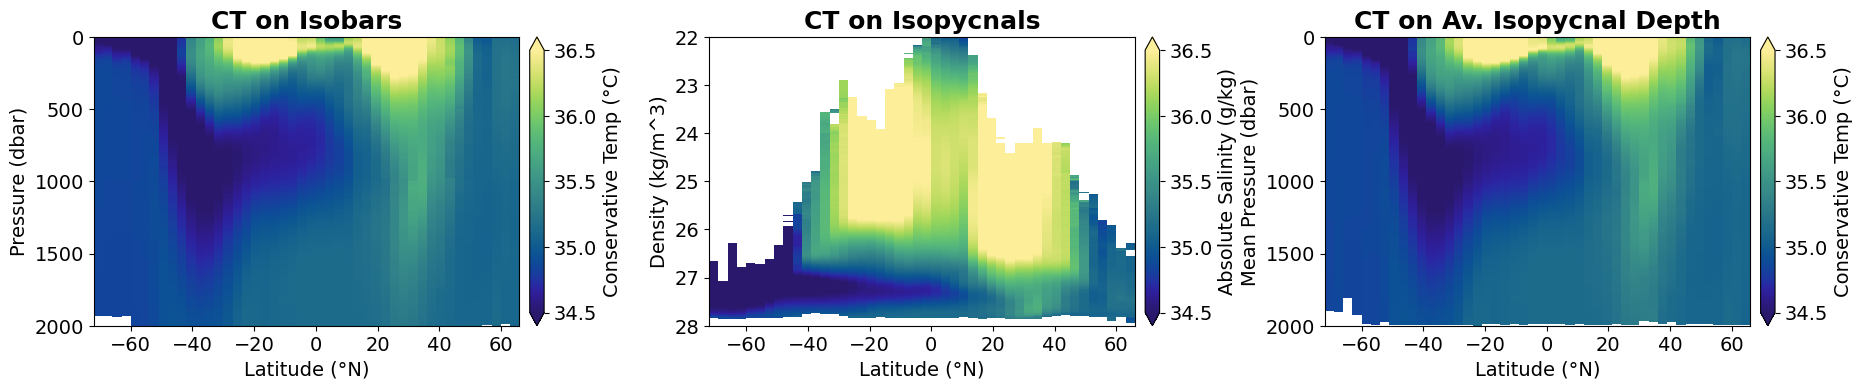

In [448]:
fig, axes = plt.subplots(1, 3, figsize=(22.5, 3.75))
ax1, ax2, ax3 = axes

ds_p_grid.SA_sort.sel(LON=-28,method='nearest').plot(x='LAT',y='PRESSURE',cmap=cmo.haline,vmin=34.5,vmax=36.5,ax=ax1,cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': 'Conservative Temp (°C)'})
ax1.set_xlim(-72,66)
ax1.set_ylim(2000,0)
ax1.set_ylabel('Pressure (dbar)')
ax1.set_xlabel('Latitude (°N)')
ax1.set_title('CT on Isobars')

ds_r_grid.SA_sort.sel(LON=-28,method='nearest').plot(x='LAT',y='DENSITY',cmap=cmo.haline,vmin=34.5,vmax=36.5,ax=ax2,cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': 'Absolute Salinity (g/kg)'})
ax2.set_xlim(-72,66)
ax2.set_ylim(28,22)
ax2.set_ylabel('Density (kg/m^3)')
ax2.set_xlabel('Latitude (°N)')
ax2.set_title('CT on Isopycnals')

ds_pbar_grid.SA_sort.sel(LON=-28,method='nearest').plot(x='LAT',y='PRESSURE_mean',cmap=cmo.haline,vmin=34.5,vmax=36.5,ax=ax3,cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': 'Conservative Temp (°C)'})
ax3.set_xlim(-72,66)
ax3.set_ylim(2000,0)
ax3.set_ylabel('Mean Pressure (dbar)')
ax3.set_xlabel('Latitude (°N)')
ax3.set_title('CT on Av. Isopycnal Depth')